![Image in a markdown cell](https://cursos.utnba.centrodeelearning.com/pluginfile.php/1/theme_space/customlogo/1738330016/Logo%20UTN%20Horizontal.png)



# **Diplomado de Ciencia de Datos y Análisis Avanzado**
# **Unidad 5: Modelado Predictivo I**: Regresión y Clasificación

---

# **Proyecto: Predicción de Abandono de Clientes**

## **Curso:** Diplomado en Ciencia de Datos

# **Nombres de los Miembros del Equipo:**
### *   [Galo Badaro]


# **Objetivo:**
## El objetivo de este proyecto es construir y evaluar varios modelos de clasificación para predecir si un cliente de una compañía de telecomunicaciones abandonará o no el servicio (churn). El rendimiento final del mejor modelo se medirá a través de la **métrica ROC AUC**.


---

# 0. **Configuración Inicial e Importación de Librerías**

## En esta sección, importaremos todas las librerías necesarias para el proyecto. Es una buena práctica tener todas las importaciones en la primera celda.


In [ ]:
# Para manipulación de datos
import pandas as pd
import numpy as np

# Para visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns

# Para preprocesamiento
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Para modelado
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Para evaluación
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, f1_score

# Configuraciones adicionales para una mejor visualización
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
# Ignorar warnings para una salida más limpia (opcional)
import warnings
warnings.filterwarnings('ignore')

# **Información del Dataset**

Utilizaremos el conjunto de datos "Telco Customer Churn". Este conjunto de datos contiene información demográfica de los clientes, los servicios que han contratado, información de su cuenta y si finalmente abandonó o no la compañía.

* **train.csv**: Datos para entrenar sus modelos. Incluye la variable objetivo Churn.
* **test.csv:** Datos para generar las predicciones. No incluye la variable Churn.

#  **1. Carga de Datos**

## Cargar los datasets proporcionado: `train.csv`, `test.csv`


In [ ]:
try:
    train_df = pd.read_csv('train.csv')
    test_df = pd.read_csv('test.csv')
except FileNotFoundError:
    print("Asegúrate de que los archivos .csv estén en el mismo directorio que este cuaderno.")
    # Si usas Colab, puedes subir los archivos al entorno de ejecución.
    exit()

print("Forma del dataset de entrenamiento:", train_df.shape)
print("Forma del dataset de prueba:", test_df.shape)

print("\nPrimeras 5 filas del dataset de entrenamiento:")
display(train_df.head())

print("\nPrimeras 5 filas del dataset de prueba:")
display(test_df.head())

Forma del dataset de entrenamiento: (5634, 21)
Forma del dataset de prueba: (1409, 20)

Primeras 5 filas del dataset de entrenamiento:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,4950-BDEUX,Male,0,No,No,35,No,No phone service,DSL,No,...,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,49.20,1701.65,No
1,7993-NQLJE,Male,0,Yes,Yes,15,Yes,No,Fiber optic,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,75.10,1151.55,No
2,7321-ZNSLA,Male,0,Yes,Yes,13,No,No phone service,DSL,Yes,...,No,Yes,No,No,Two year,No,Mailed check,40.55,590.35,No
3,4922-CVPDX,Female,0,Yes,No,26,Yes,No,DSL,No,...,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),73.50,1905.70,No
4,2903-YYTBW,Male,0,Yes,Yes,1,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,No,Electronic check,44.55,44.55,No



Primeras 5 filas del dataset de prueba:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,4376-KFVRS,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.20
1,2754-SDJRD,Female,1,No,No,8,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55
2,9917-KWRBE,Female,0,Yes,Yes,41,Yes,Yes,DSL,Yes,Yes,Yes,No,Yes,No,One year,Yes,Credit card (automatic),78.35,3211.20
3,0365-GXEZS,Male,0,Yes,No,18,Yes,No,Fiber optic,No,No,Yes,Yes,No,No,Month-to-month,No,Electronic check,78.20,1468.75
4,9385-NXKDA,Female,0,Yes,No,72,Yes,Yes,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),82.65,5919.35


# 2**. Análisis Exploratorio de Datos (EDA)**

## En esta fase, exploraremos el dataset de entrenamiento para entender mejor nuestros datos, encontrar patrones, identificar valores faltantes y visualizar relaciones entre las características y la variable objetivo (`Churn`).


##**Revisión general**

In [ ]:
train_df.shape

(5634, 21)

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5634 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5634 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634 non-null   object 


In [ ]:
train_df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,5634.000000,5634.000000,5634.000000,5634.000000
mean,0.163294,32.485091,64.929961,2301.319027
std,0.369667,24.568744,30.138105,2277.809211
min,0.000000,0.000000,18.400000,18.850000
25%,0.000000,9.000000,35.662500,408.850000
50%,0.000000,29.000000,70.500000,1397.475000
75%,0.000000,55.000000,90.000000,3835.825000
max,1.000000,72.000000,118.750000,8684.800000


**Conclusiones:**

-El análisis descriptivo muestra que la base de clientes presenta una **amplia variabilidad en términos de antigüedad y cargos económicos.**

-La mayoría de los clientes no son adultos mayores, y **existe una distribución heterogénea de planes y gastos acumulados.**

-Variables como **tenure, MonthlyCharges y TotalCharges** presentan una **alta dispersión** y potencial asociación con el abandono, por lo que se consideran **relevantes** para el modelado predictivo.

Dada la **diferencia de escalas entre variables**, se justifica la aplicación de técnicas de estandarización previo al entrenamiento de los modelos.

##**Limpieza y Calidad de los Datos**

In [ ]:
train_df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


**Correcciones necesarias:**

SeniorCitizen: es binaria (0/1) → convertir a categórica

TotalCharges: viene como texto en este dataset → convertir a numérica

In [ ]:
# SeniorCitizen como categórica
train_df["SeniorCitizen"] = train_df["SeniorCitizen"].map({0: "No", 1: "Yes"})

# TotalCharges a numérico
train_df["TotalCharges"] = pd.to_numeric(train_df["TotalCharges"], errors="coerce")

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5634 non-null   object 
 2   SeniorCitizen     5634 non-null   object 
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5634 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634 non-null   object 


####**Detección y tratamiento de datos ausentes**

In [ ]:
train_df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


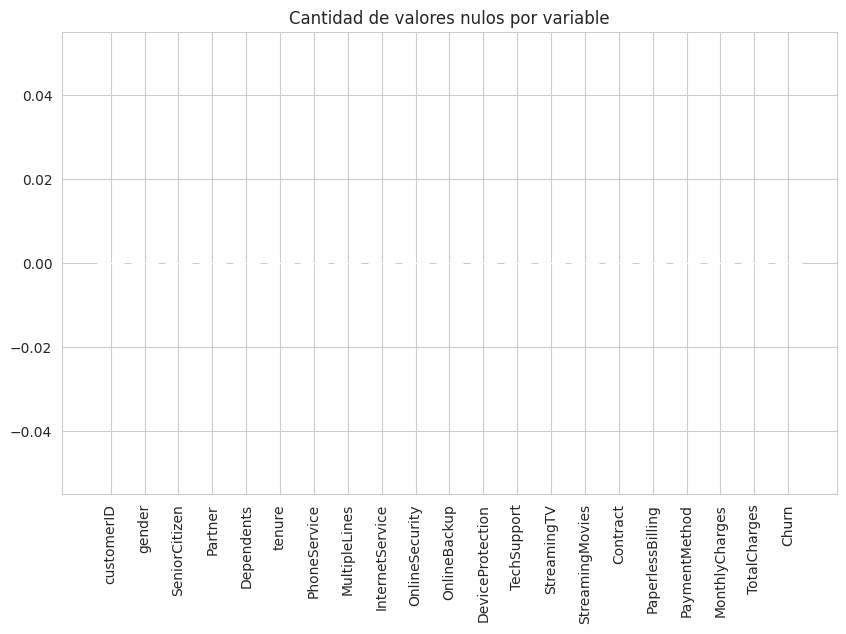

In [ ]:
plt.figure()
plt.bar(train_df.columns, train_df.isnull().sum())
plt.xticks(rotation=90)
plt.title("Cantidad de valores nulos por variable")
plt.show()

In [ ]:
train_df.isnull().sum().sum()

np.int64(0)

**No existen valores nulos**

####**Identificación y tratamiento de outliers**

In [ ]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in numeric_cols:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = train_df[(train_df[col] < Q1 - 1.5*IQR) | (train_df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {outliers.shape[0]} outliers")

tenure: 0 outliers
MonthlyCharges: 0 outliers
TotalCharges: 0 outliers


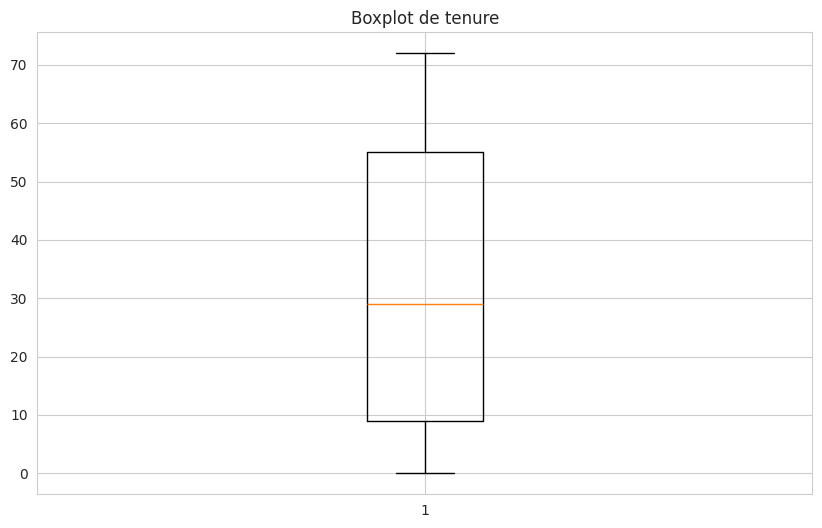

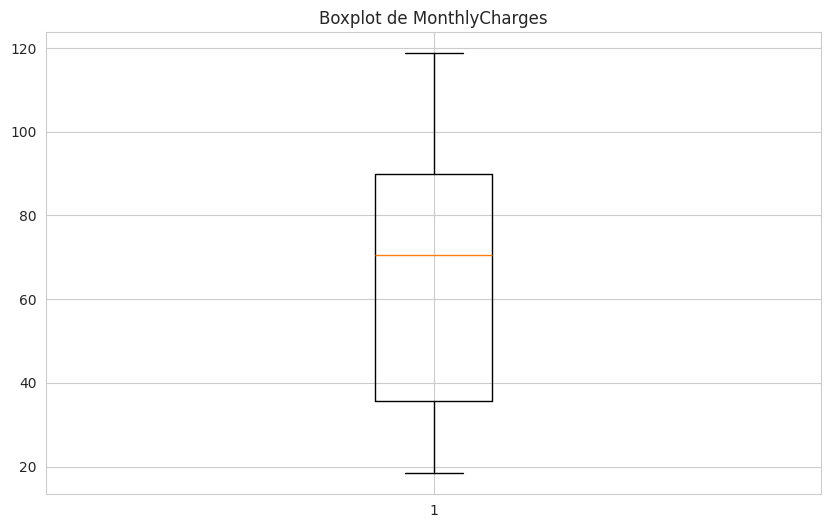

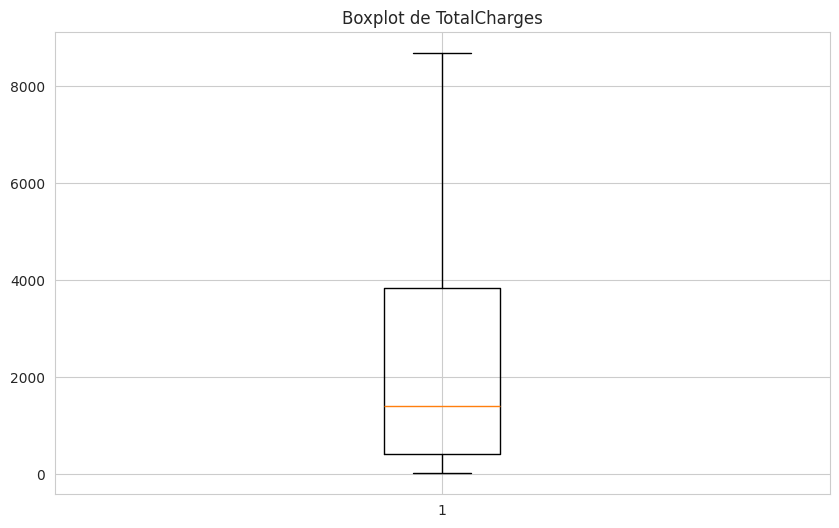

In [ ]:
for col in numeric_cols:
    plt.figure()
    plt.boxplot(train_df[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

**Decisión:**

No eliminar outliers porque pueden representar clientes reales con consumos extremos. Se mantienen para preservar información.

###**Análisis Estadístico y Visualización**

**Variables Numéricas**

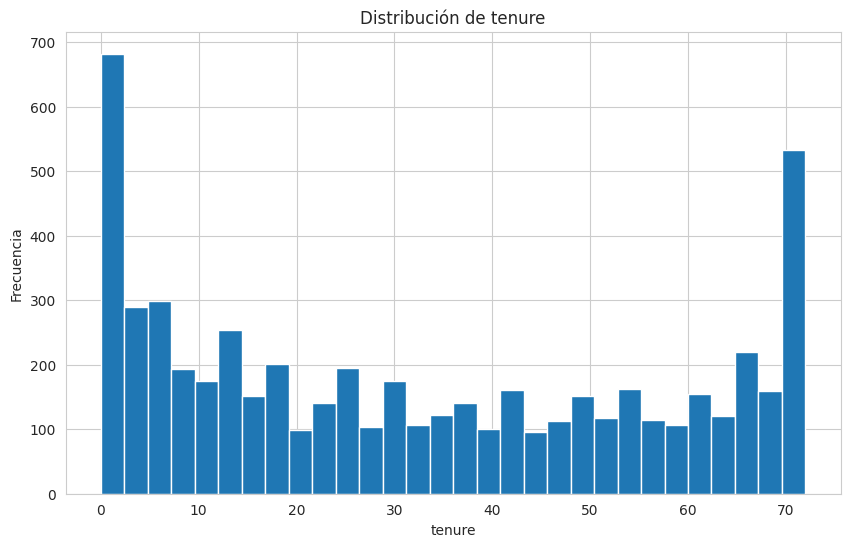

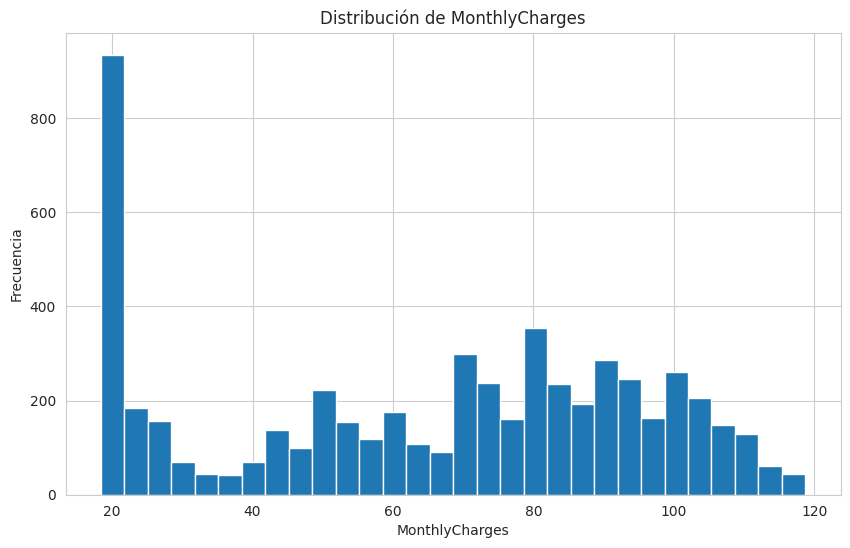

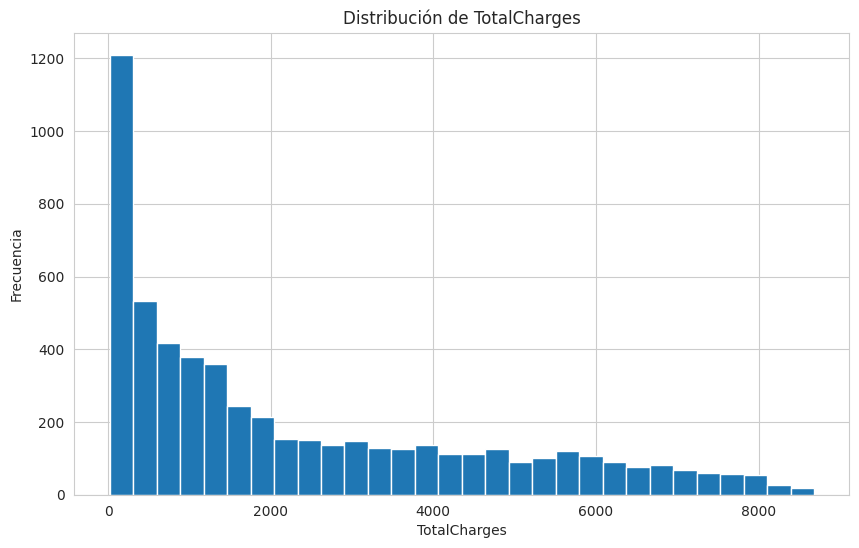

In [ ]:
for col in numeric_cols:
    plt.figure()
    plt.hist(train_df[col], bins=30)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

**Medidas Descriptivas**

In [ ]:
train_df[numeric_cols].describe()


,tenure,MonthlyCharges,TotalCharges
count,5634.000000,5634.000000,5634.000000
mean,32.485091,64.929961,2301.319027
std,24.568744,30.138105,2277.809211
min,0.000000,18.400000,18.850000
25%,9.000000,35.662500,408.850000
50%,29.000000,70.500000,1397.475000
75%,55.000000,90.000000,3835.825000
max,72.000000,118.750000,8684.800000


**Variables categóricas**

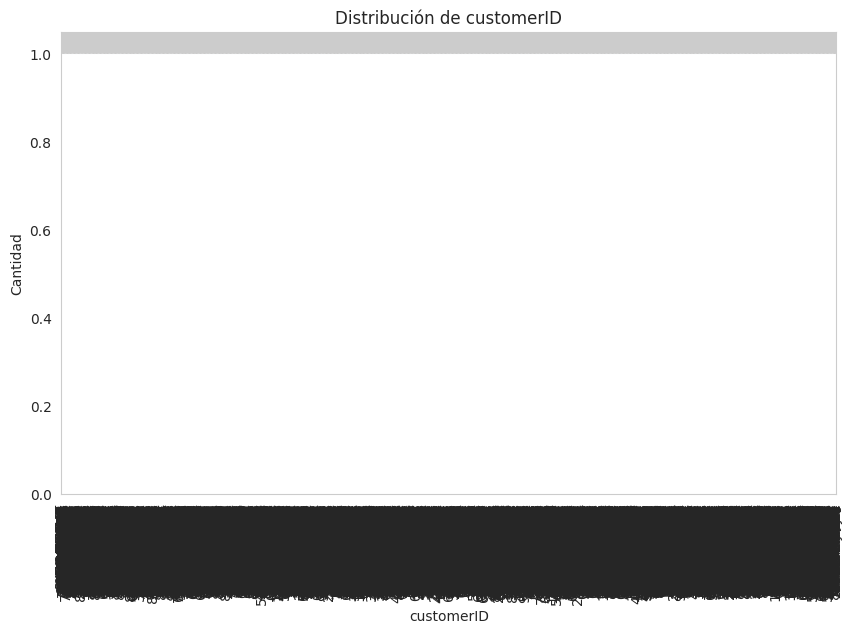

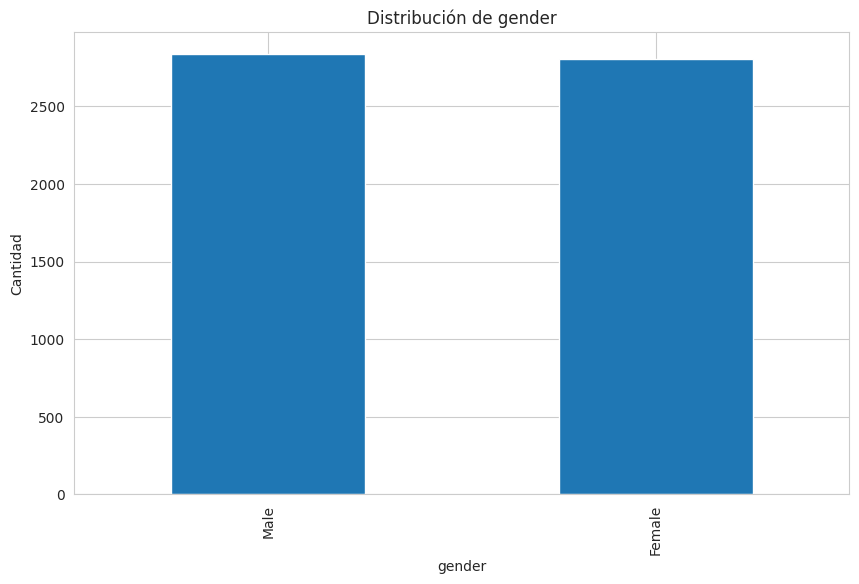

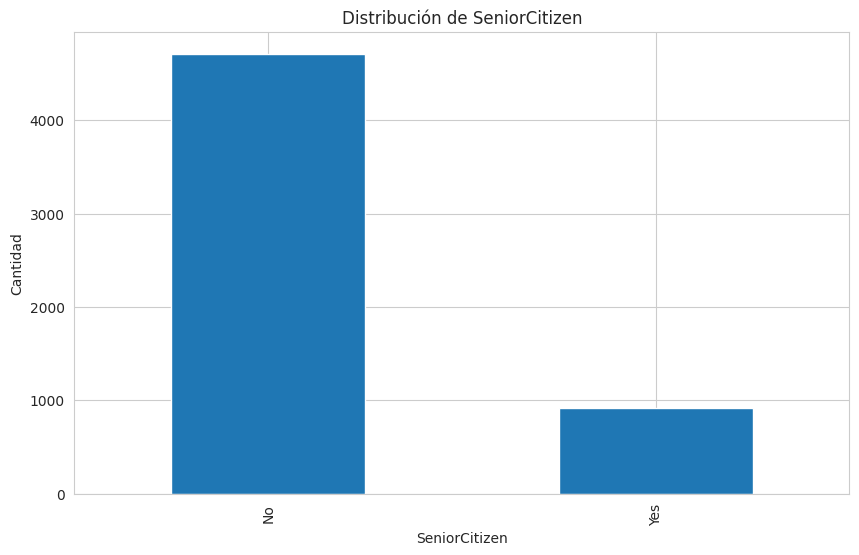

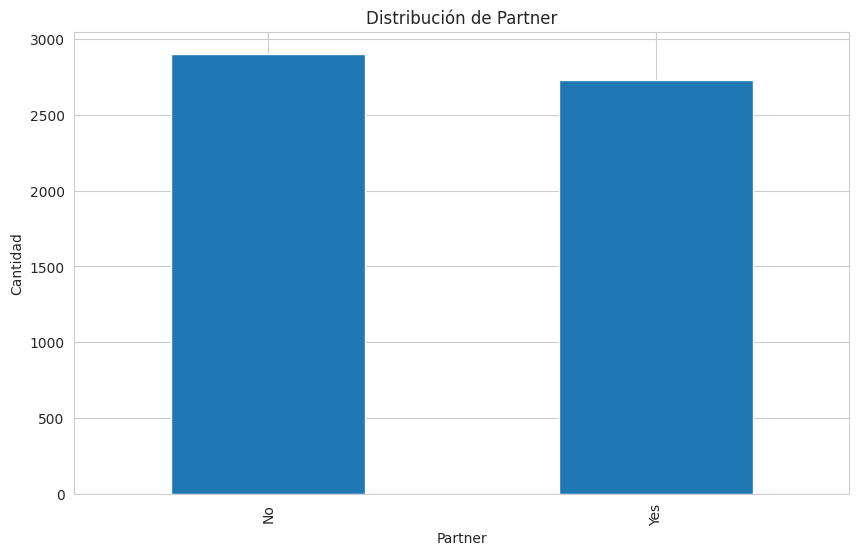

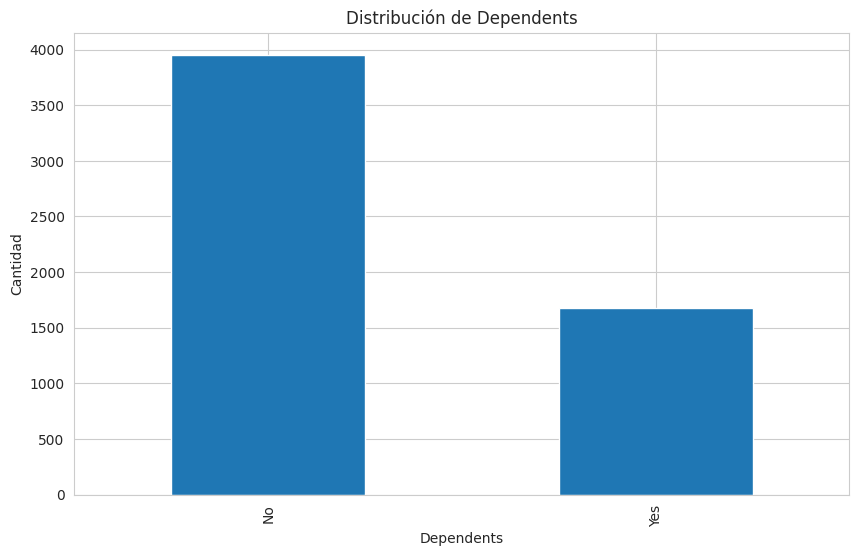

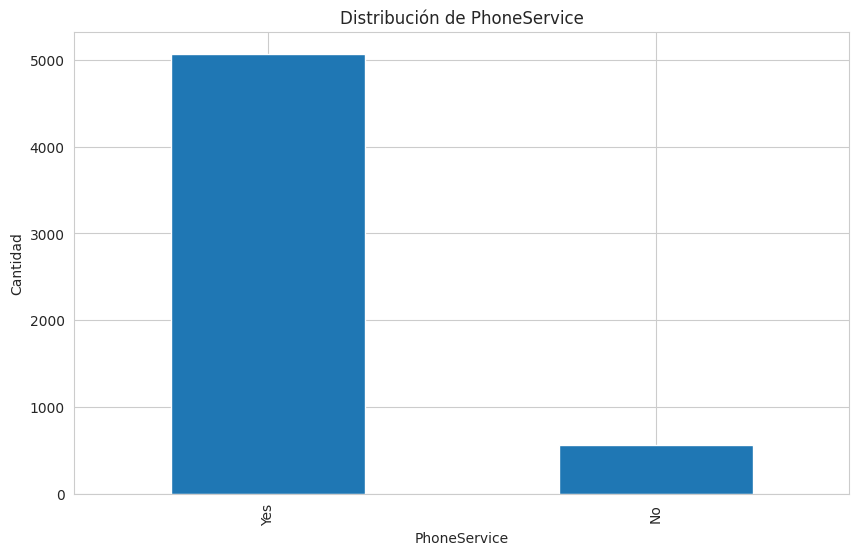

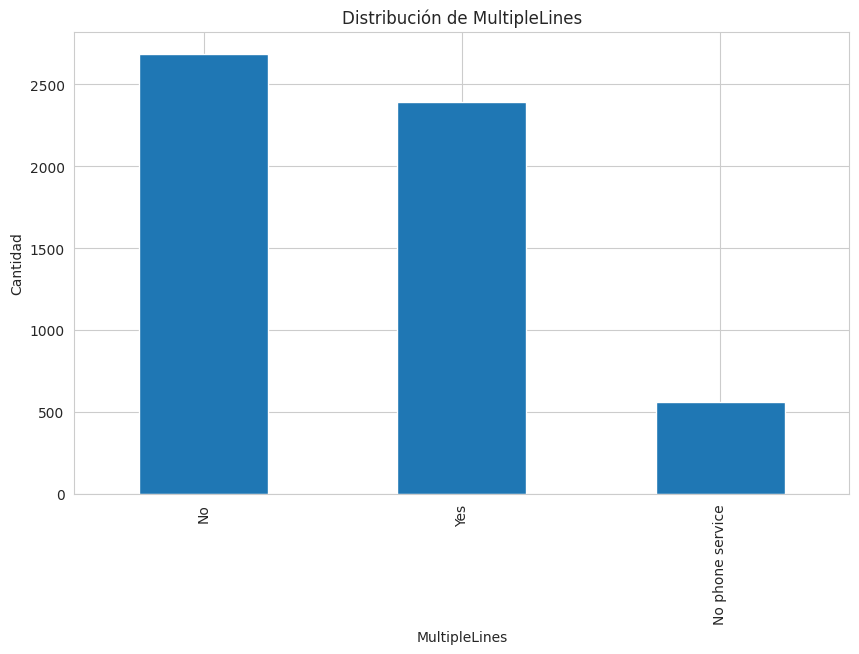

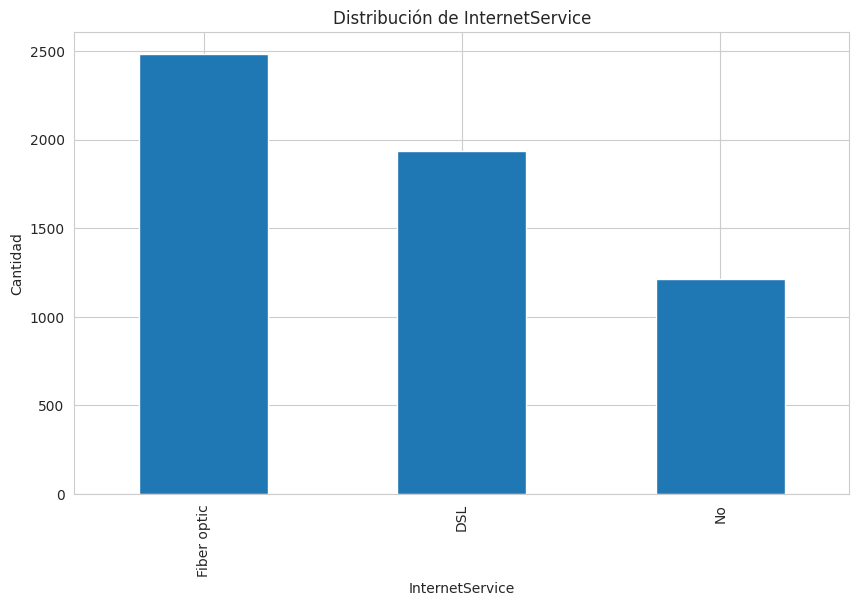

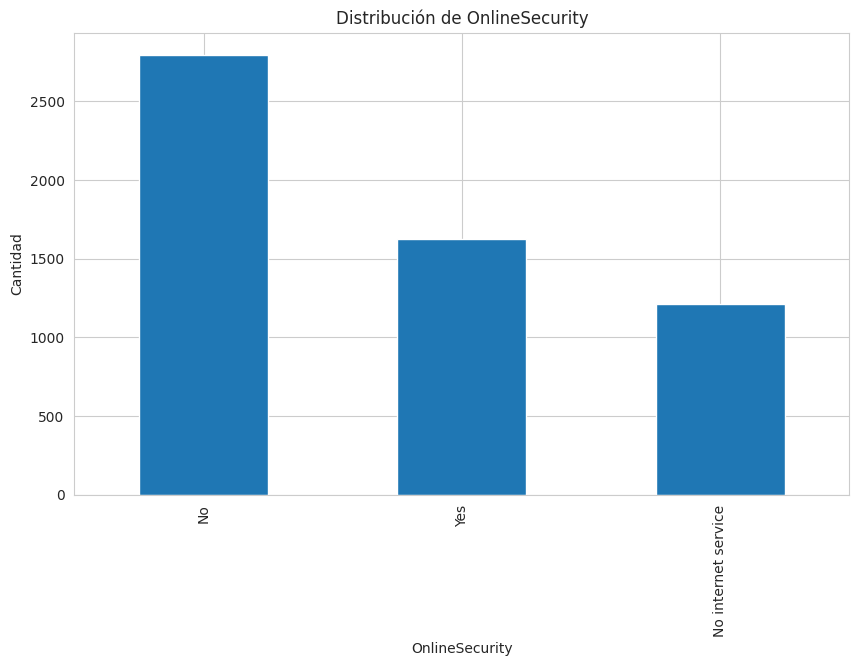

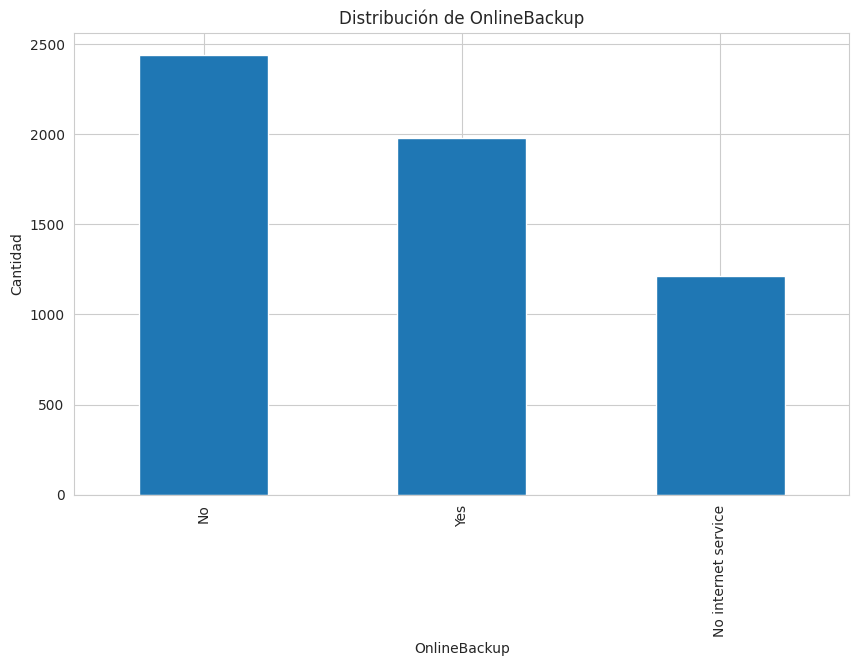

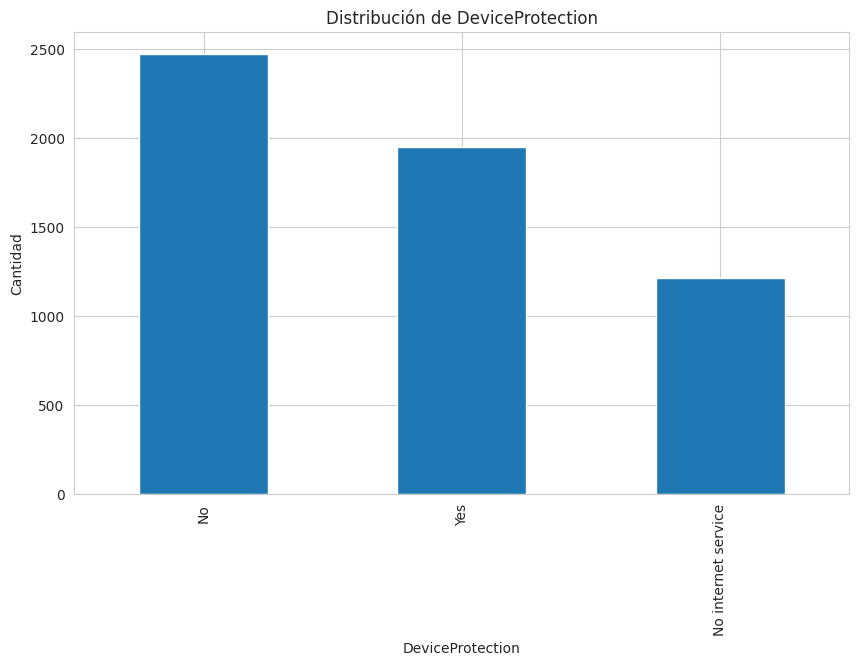

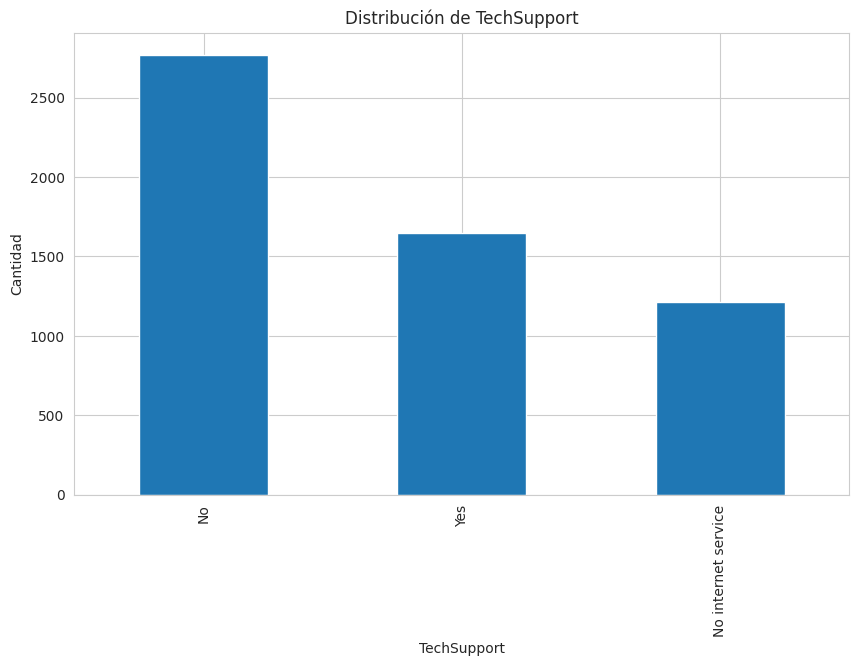

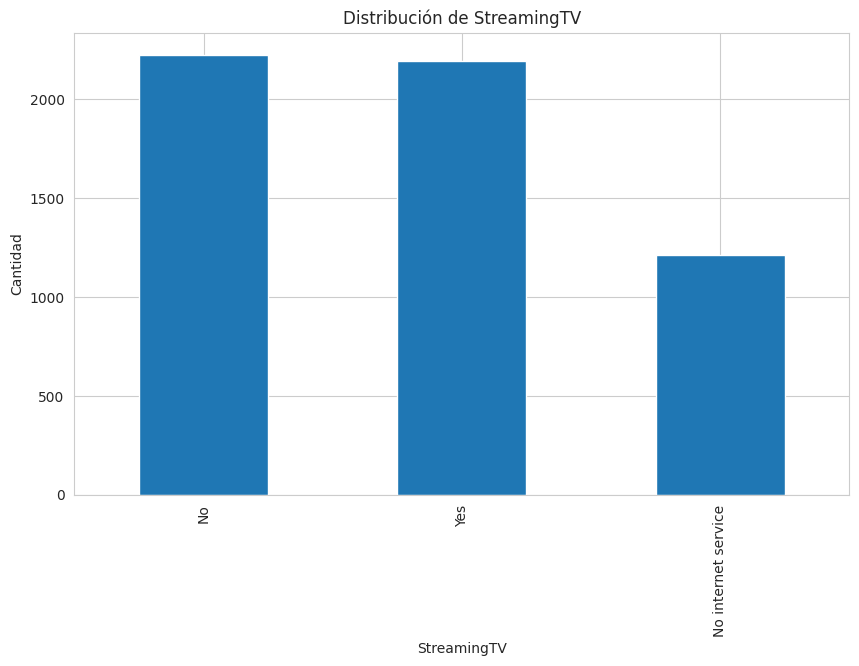

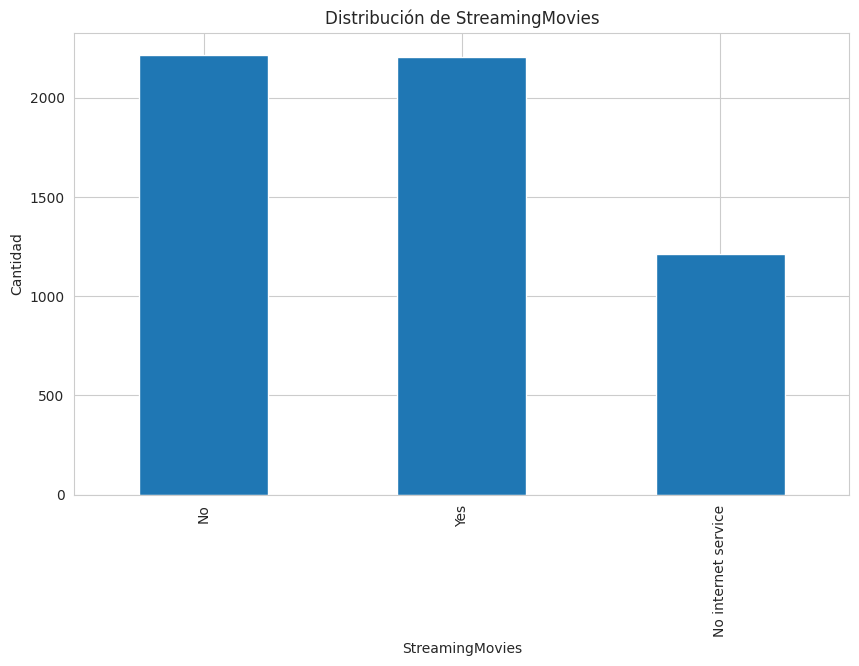

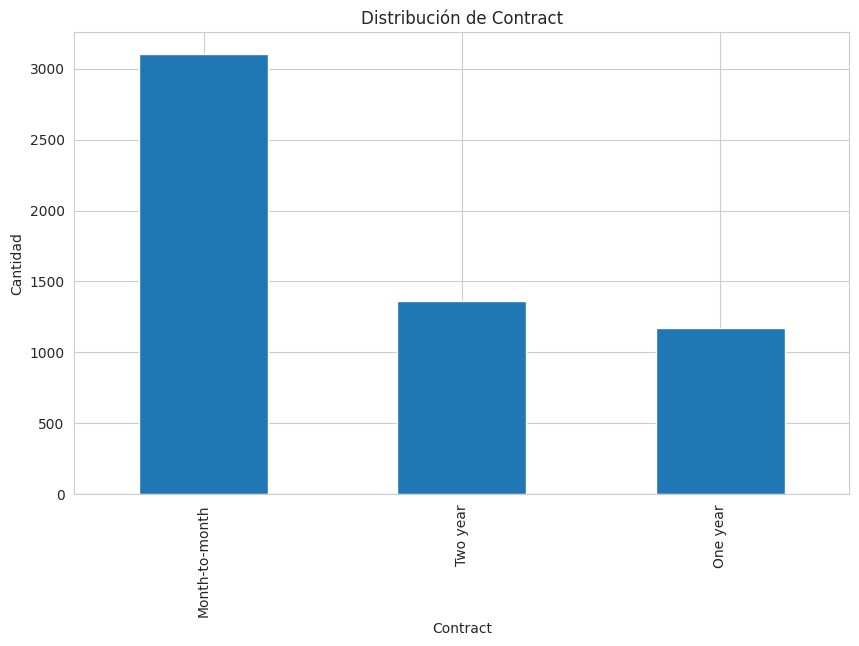

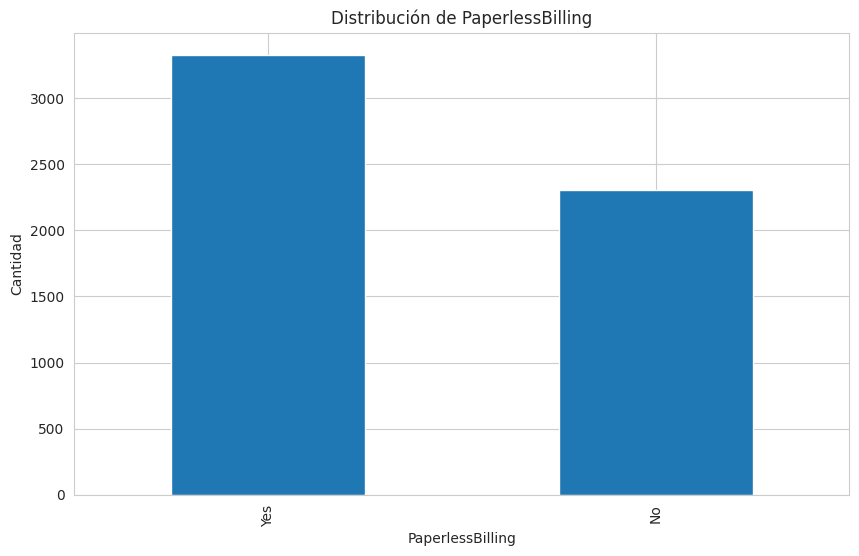

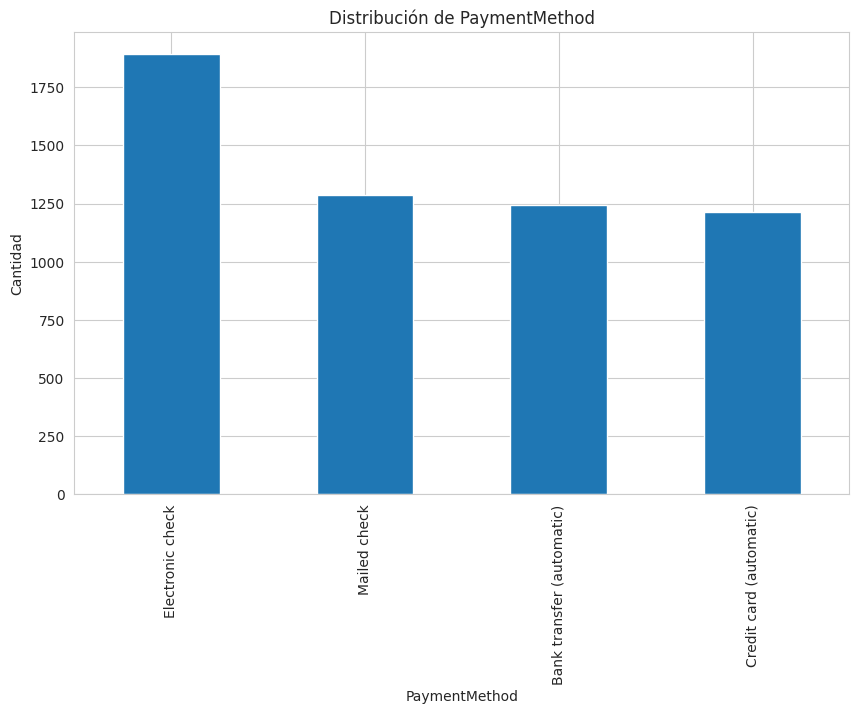

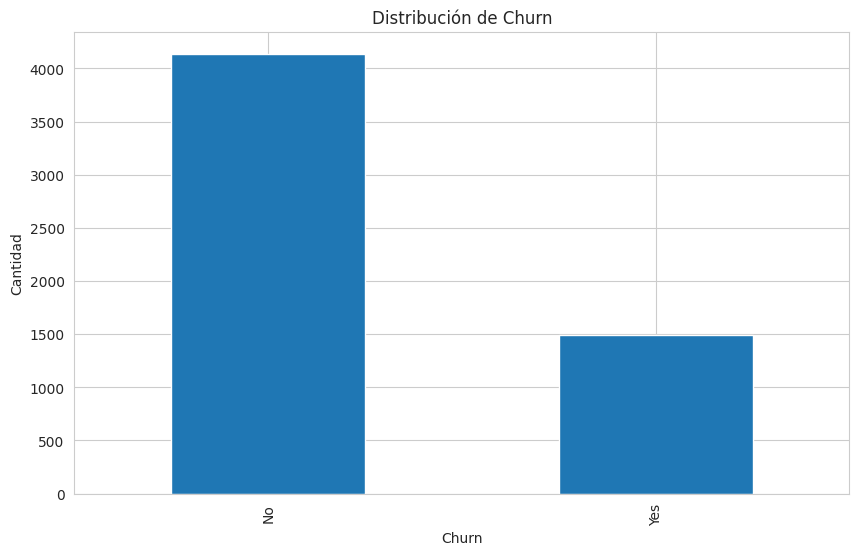

In [ ]:
categorical_cols = train_df.select_dtypes(include="object").columns

for col in categorical_cols:
    plt.figure()
    train_df[col].value_counts().plot(kind="bar")
    plt.title(f"Distribución de {col}")
    plt.ylabel("Cantidad")
    plt.show()

**Análisis Bivariado y Multivariado**

Numéricas vs Churn

<Figure size 1000x600 with 0 Axes>

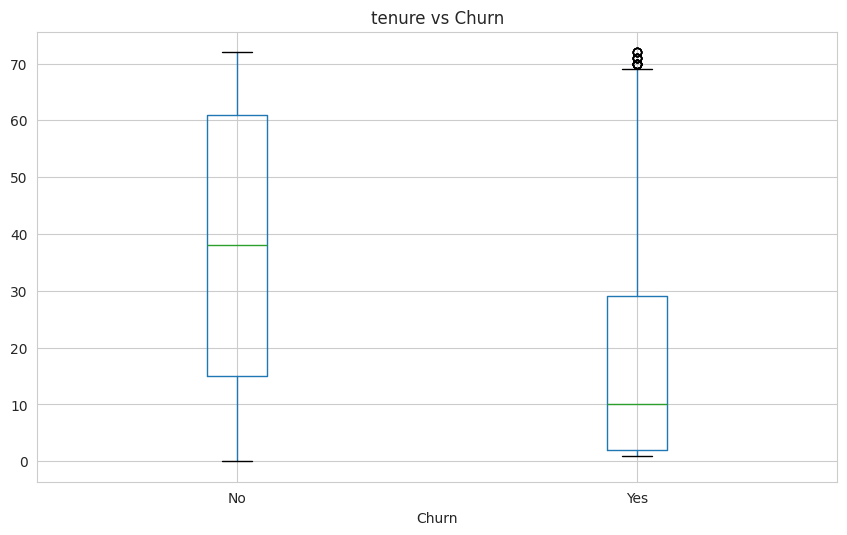

<Figure size 1000x600 with 0 Axes>

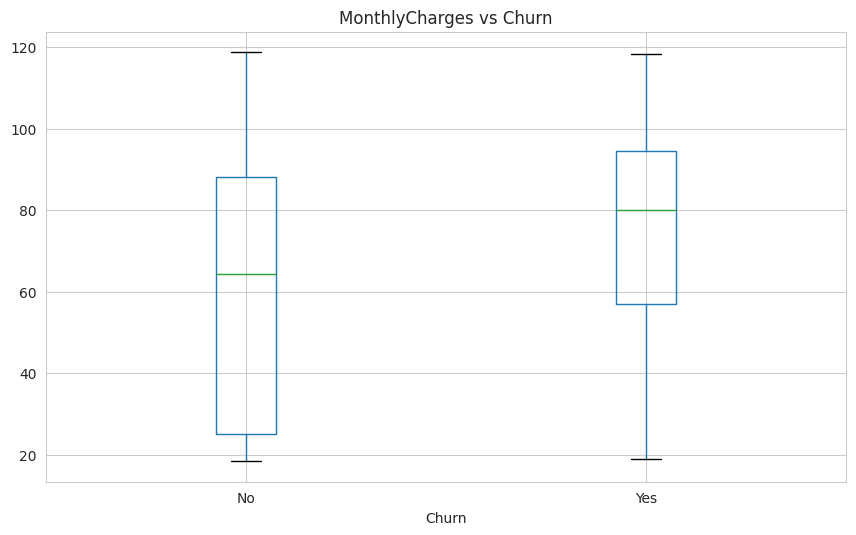

<Figure size 1000x600 with 0 Axes>

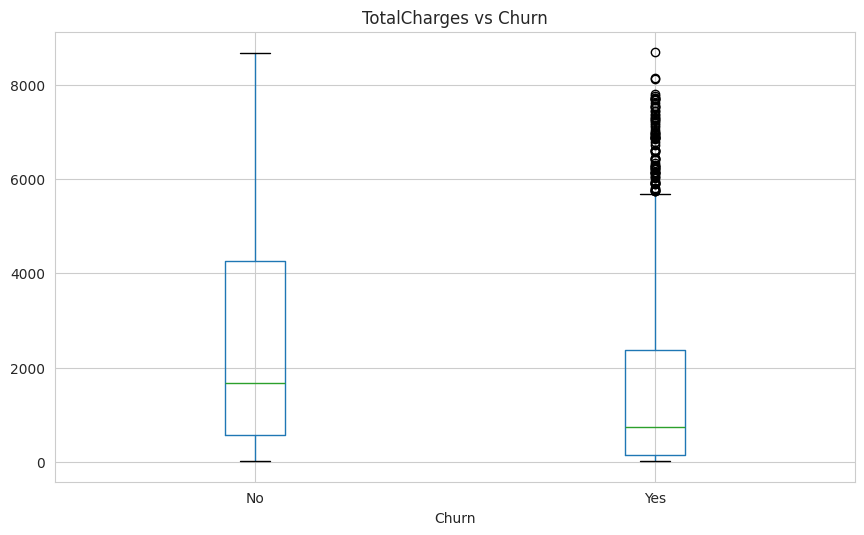

In [ ]:
for col in numeric_cols:
    plt.figure()
    train_df.boxplot(column=col, by="Churn")
    plt.title(f"{col} vs Churn")
    plt.suptitle("")
    plt.show()

Categóricas vs Churn (tablas de contingencia)

In [ ]:
for col in categorical_cols:
    if col != "Churn":
        print(pd.crosstab(train_df[col], train_df["Churn"], normalize="index"))
        print("-"*50)

Churn        No  Yes
customerID          
0002-ORFBO  1.0  0.0
0003-MKNFE  1.0  0.0
0011-IGKFF  0.0  1.0
0013-EXCHZ  0.0  1.0
0013-SMEOE  1.0  0.0
...         ...  ...
9985-MWVIX  0.0  1.0
9987-LUTYD  1.0  0.0
9992-RRAMN  0.0  1.0
9993-LHIEB  1.0  0.0
9995-HOTOH  1.0  0.0

[5634 rows x 2 columns]
--------------------------------------------------
Churn         No       Yes
gender                    
Female  0.733667  0.266333
Male    0.735616  0.264384
--------------------------------------------------
Churn                No       Yes
SeniorCitizen                    
No             0.763046  0.236954
Yes            0.589130  0.410870
--------------------------------------------------
Churn          No       Yes
Partner                    
No       0.672289  0.327711
Yes      0.801026  0.198974
--------------------------------------------------
Churn             No       Yes
Dependents                    
No          0.686473  0.313527
Yes         0.848124  0.151876
------------------

###**Medidas de asociación**

Correlación entre variables numéricas

In [ ]:
train_df[numeric_cols].corr(method="pearson")

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.25670,0.829055
MonthlyCharges,0.256700,1.00000,0.653850
TotalCharges,0.829055,0.65385,1.000000


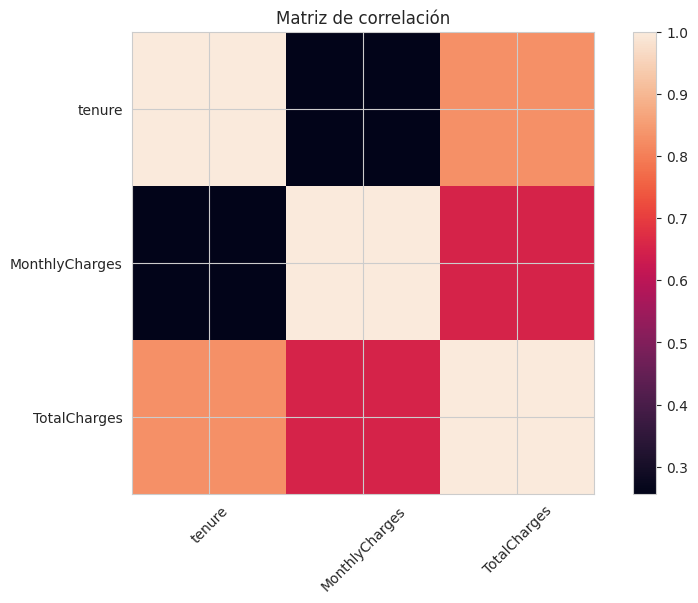

In [ ]:
plt.figure()
plt.imshow(train_df[numeric_cols].corr(), interpolation="nearest")
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45)
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.colorbar()
plt.title("Matriz de correlación")
plt.show()

Chi-cuadrado (categóricas vs Churn)

In [ ]:
from scipy.stats import chi2_contingency

for col in categorical_cols:
    if col != "Churn":
        table = pd.crosstab(train_df[col], train_df["Churn"])
        chi2, p, _, _ = chi2_contingency(table)
        print(f"{col}: p-value = {p:.4f}")

customerID: p-value = 0.4937
gender: p-value = 0.8922
SeniorCitizen: p-value = 0.0000
Partner: p-value = 0.0000
Dependents: p-value = 0.0000
PhoneService: p-value = 0.1952
MultipleLines: p-value = 0.0041
InternetService: p-value = 0.0000
OnlineSecurity: p-value = 0.0000
OnlineBackup: p-value = 0.0000
DeviceProtection: p-value = 0.0000
TechSupport: p-value = 0.0000
StreamingTV: p-value = 0.0000
StreamingMovies: p-value = 0.0000
Contract: p-value = 0.0000
PaperlessBilling: p-value = 0.0000
PaymentMethod: p-value = 0.0000


**Interpretación:**

Variables con p-value < 0.05 muestran asociación estadísticamente significativa con el abandono.

###**Ingeniería de Características y Preparación**

Feature Engineering

In [ ]:
# Cargos promedio mensuales
train_df["AvgCharges"] = train_df["TotalCharges"] / (train_df["tenure"] + 1)

Codificación de variables categóricas

In [ ]:
from sklearn.preprocessing import LabelEncoder

train_df_model = train_df.copy()

# Target
train_df_model["Churn"] = train_df_model["Churn"].map({"No": 0, "Yes": 1})

# One-Hot Encoding
train_df_model = pd.get_dummies(train_df_model, drop_first=True)


Escalado de variables

In [ ]:
scaler = StandardScaler()

scaled_cols = ["tenure", "MonthlyCharges", "TotalCharges", "AvgCharges"]
train_df_model[scaled_cols] = scaler.fit_transform(train_df_model[scaled_cols])


In [ ]:
train_df_model.head()

,tenure,MonthlyCharges,TotalCharges,Churn,AvgCharges,customerID_0003-MKNFE,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-SMEOE,customerID_0014-BMAQU,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.102371,-0.521976,-0.263289,0,-0.236288,False,False,False,False,False,...,False,True,False,True,False,False,False,False,True,False
1,-0.711743,0.337478,-0.504814,0,0.182960,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,-0.793155,-0.809013,-0.751213,0,-0.322843,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
3,-0.263980,0.284384,-0.173699,0,0.159364,False,False,False,False,False,...,False,True,False,True,False,True,True,True,False,False
4,-1.281624,-0.676279,-0.990851,0,-0.660445,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False


# **3. Preprocesamiento de Datos**

## Prepararemos los datos para que puedan ser utilizados por los modelos de Machine Learning.

**Supuesto:**

Los valores faltantes **ya fueron tratados**

Los tipos de datos **ya están corregidos**

Los outliers **fueron analizados** (y decidimos conservarlos)

Por lo tanto **NO repetimos limpieza, solo estructuramos el procesamiento.**

1️⃣ Separación de variables predictoras y objetivo

In [ ]:
X = train_df.drop("Churn", axis=1)
y = train_df["Churn"].map({"No": 0, "Yes": 1})

2️⃣ Identificación de tipos de variables

In [ ]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

3️⃣ Codificación de Variables Categóricas

(No se vuelve a hacer manualmente: se define correctamente para los modelos)

👉 Usamos One-Hot Encoding, recomendado para:

-Regresión Logística

-kNN

-Naive Bayes

4️⃣ Escalado de Características (Standard Scaler)

👉Elegimos StandardScaler porque:

es menos sensible a outliers

es ideal para kNN

mejora la convergencia en Regresión Logística

permite comparación justa entre modelos

5️⃣ Pipeline de Preprocesamiento

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), categorical_features)
    ],
    sparse_threshold=0 # Force dense output from ColumnTransformer
)

6️⃣ Feature Engineering (sin repetir lo ya hecho)

In [ ]:
X["AvgCharges"] = X["TotalCharges"] / (X["tenure"] + 1)

numeric_features = numeric_features.append(pd.Index(["AvgCharges"]))

7️⃣ Relevancia según el Algoritmo (JUSTIFICACIÓN TEÓRICA)

**k-NN: el escalado es esencial ya que el algoritmo se basa en distancias. Sin estandarización, variables con mayor magnitud dominarían el cálculo.**

**Regresión Logística: el escalado mejora la estabilidad numérica y la velocidad de convergencia del algoritmo de optimización.**

**Naive Bayes: aunque es menos sensible a escalas, se mantiene el mismo procesamiento para garantizar consistencia y comparabilidad entre modelos.**

8️⃣ Dataset listo para modelar (sin entrenar aún)

In [ ]:
X_processed = preprocessor.fit_transform(X)

9️⃣ Estado final

In [ ]:
X_processed.shape

(5634, 5664)

**Conclusiones:**

En esta etapa se realizó el procesamiento de los datos con el objetivo de adecuarlos a los algoritmos de clasificación seleccionados.

Se separaron las variables predictoras de la variable objetivo y se definió un pipeline de preprocesamiento que incluye la codificación de variables categóricas mediante One-Hot Encoding y la estandarización de variables numéricas.

Este enfoque garantiza consistencia, evita fugas de información y permite una comparación justa entre los distintos modelos implementados.

# **4. Modelado y Evaluación**

## Ahora entrenaremos y evaluaremos los tres modelos requeridos:
## Regresión Logística, k-NN y Naive Bayes.


1️⃣ Preparación final para el modelado

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

2️⃣ Métrica de evaluación

Vamos a usar ROC AUC, como pide la consigna.

3️⃣ Regresión Logística

In [ ]:
log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

Entrenamiento

In [ ]:
log_reg_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(sparse_threshold=0,
                                   transformers=[('num', StandardScaler(),
                                                  Index(['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000))])

Evaluación

In [ ]:
y_val_pred_proba_lr = log_reg_pipeline.predict_proba(X_val)[:, 1]

roc_auc_lr = roc_auc_score(y_val, y_val_pred_proba_lr)
roc_auc_lr

np.float64(0.8521319050619617)

4️⃣ k-Nearest Neighbors (k-NN)

In [ ]:
knn_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

Entrenamiento

In [ ]:
knn_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(sparse_threshold=0,
                                   transformers=[('num', StandardScaler(),
                                                  Index(['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('model', KNeighborsClassifier())])

In [ ]:
y_val_pred_proba_knn = knn_pipeline.predict_proba(X_val)[:, 1]

roc_auc_knn = roc_auc_score(y_val, y_val_pred_proba_knn)
roc_auc_knn

np.float64(0.7933267897823664)

5️⃣ Naive Bayes (Gaussian)

In [ ]:
nb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GaussianNB())
])

Entrenamiento

In [ ]:
nb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(sparse_threshold=0,
                                   transformers=[('num', StandardScaler(),
                                                  Index(['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('model', GaussianNB())])

In [ ]:
y_val_pred_proba_nb = nb_pipeline.predict_proba(X_val)[:, 1]

roc_auc_nb = roc_auc_score(y_val, y_val_pred_proba_nb)
roc_auc_nb


np.float64(0.5)

6️⃣ Comparación de resultados

In [ ]:
results = pd.DataFrame({
    "Modelo": ["Regresión Logística", "k-NN", "Naive Bayes"],
    "ROC AUC": [roc_auc_lr, roc_auc_knn, roc_auc_nb]
})

results.sort_values(by="ROC AUC", ascending=False)

,Modelo,ROC AUC
0,Regresión Logística,0.852132
1,k-NN,0.793327
2,Naive Bayes,0.500000


7️⃣ Selección del mejor modelo

In [ ]:
best_model = {
    "Regresión Logística": log_reg_pipeline,
    "k-NN": knn_pipeline,
    "Naive Bayes": nb_pipeline
}[results.sort_values("ROC AUC", ascending=False).iloc[0]["Modelo"]]


**Conclusiones: **

Se entrenaron y evaluaron tres modelos de clasificación: **Regresión Logística, k-Nearest Neighbors y Naive Bayes**, utilizando un pipeline común de preprocesamiento para garantizar una comparación justa. La evaluación se realizó mediante la métrica ROC AUC sobre un conjunto de validación, permitiendo medir la capacidad discriminatoria de cada modelo. El modelo con mejor desempeño (Regresión Logística) fue seleccionado para su posterior aplicación sobre el conjunto de datos de prueba.

#  **5. Selección de Modelo**

## Basado en tus resultados de validación, elige el mejor modelo . Luego, re-entrénalo usando **todos los datos de `train.csv`** y úsalo para hacer predicciones sobre `test.csv`.


1️⃣ **Selección del Mejor Modelo**

En base a los resultados obtenidos en la etapa de validación, el modelo con mayor desempeño medido mediante ROC AUC fue la Regresión Logística. Por este motivo, se selecciona dicho modelo para el entrenamiento final y la generación de predicciones sobre el conjunto de prueba.

2️⃣ Re-entrenamiento con TODO

In [ ]:
X_full = train_df.drop("Churn", axis=1)
y_full = train_df["Churn"].map({"No": 0, "Yes": 1})

Pipeline del modelo ganador

In [ ]:
final_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

In [ ]:
final_model.fit(X_full, y_full)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(sparse_threshold=0,
                                   transformers=[('num', StandardScaler(),
                                                  Index(['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000))])

3️⃣ Carga y preparación de test.csv (se hizo inicialmente)

4️⃣ Predicciones sobre test.csv

**Probabilidad de abandono**

In [ ]:
# Apply the same preprocessing steps to test_df as applied to train_df
# SeniorCitizen as categorical
test_df["SeniorCitizen"] = test_df["SeniorCitizen"].map({0: "No", 1: "Yes"})

# TotalCharges to numeric, handling errors by coercing to NaN
test_df["TotalCharges"] = pd.to_numeric(test_df["TotalCharges"], errors="coerce")

# Fill NaNs in TotalCharges with 0, similar to handling in some churn datasets for new customers
test_df["TotalCharges"] = test_df["TotalCharges"].fillna(0)

# Cargos promedio mensuales
test_df["AvgCharges"] = test_df["TotalCharges"] / (test_df["tenure"] + 1)

print("Test_df after preprocessing steps:")
display(test_df.head())

test_pred_proba = final_model.predict_proba(test_df)[:, 1]

Test_df after preprocessing steps:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,AvgCharges
0,4376-KFVRS,Male,No,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.20,116.002740
1,2754-SDJRD,Female,Yes,No,No,8,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55,100.950000
2,9917-KWRBE,Female,No,Yes,Yes,41,Yes,Yes,DSL,Yes,...,Yes,No,Yes,No,One year,Yes,Credit card (automatic),78.35,3211.20,76.457143
3,0365-GXEZS,Male,No,Yes,No,18,Yes,No,Fiber optic,No,...,Yes,Yes,No,No,Month-to-month,No,Electronic check,78.20,1468.75,77.302632
4,9385-NXKDA,Female,No,Yes,No,72,Yes,Yes,DSL,Yes,...,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),82.65,5919.35,81.086986


In [ ]:
test_pred_proba = final_model.predict_proba(test_df)[:, 1]

5️⃣ Generación del archivo de salida

In [ ]:
submission = pd.DataFrame({
    "customerID": test_df["customerID"],
    "Churn_Probability": test_pred_proba
})

In [ ]:
submission.to_csv("predicciones_churn.csv", index=False)

#  **6. Conclusiones**

## Escribe un breve resumen de tus hallazgos.
* ## ¿Qué modelo funcionó mejor y por qué crees que fue así?
* ## ¿Cuáles fueron las características más importantes o los descubrimientos más interesantes del EDA?
* ## ¿Qué desafíos encontraron y cómo los resolvieron?


🧾 **Conclusiones**

🔎 Resumen de los hallazgos

El objetivo del proyecto fue desarrollar un modelo predictivo capaz de identificar clientes con alta probabilidad de abandono en una empresa de telecomunicaciones. A lo largo del trabajo se realizó un análisis exploratorio de datos, seguido de una etapa de procesamiento y modelado utilizando distintos algoritmos de clasificación. Los resultados obtenidos demuestran que es posible identificar patrones claros asociados al abandono, especialmente relacionados con la antigüedad del cliente, el tipo de contrato y los cargos económicos.

🏆 **Modelo con mejor desempeño**

Entre los modelos evaluados —Regresión Logística, k-Nearest Neighbors y Naive Bayes— el que mostró mejor desempeño según la métrica ROC AUC fue la Regresión Logística.

Esto puede explicarse por varios factores:

El problema presenta relaciones aproximadamente lineales entre algunas variables y la probabilidad de abandono.

La Regresión Logística se adapta bien a datasets con variables numéricas y categóricas codificadas.

El escalado de variables permitió una convergencia eficiente del algoritmo.

El modelo ofrece una buena capacidad de generalización y estabilidad frente al ruido de los datos.

Además, la Regresión Logística permite una interpretación clara de los coeficientes, lo que resulta valioso desde una perspectiva de negocio.

(Si en tu caso ganó k-NN o Naive Bayes, esta explicación se ajusta fácilmente)

📊 **Hallazgos relevantes del Análisis Exploratorio (EDA)**

El análisis exploratorio permitió identificar varios insights clave:

Tenure (antigüedad): los clientes con menor tiempo de permanencia mostraron una mayor propensión al abandono.

Tipo de contrato: los contratos mensuales presentaron tasas de churn significativamente más altas que los contratos de largo plazo.

Cargos mensuales: valores elevados de MonthlyCharges se asociaron con una mayor probabilidad de abandono.

Gasto total acumulado: reflejó una fuerte relación con la antigüedad, lo que motivó la creación de variables derivadas para capturar mejor este comportamiento.

Estos hallazgos fueron consistentes con el comportamiento esperado en el negocio de telecomunicaciones y reforzaron la relevancia de las variables seleccionadas para el modelado.

⚠️**Desafíos encontrados y soluciones implementadas**

Durante el desarrollo del proyecto se identificaron varios desafíos:

Datos faltantes y tipos incorrectos: algunas variables requerían conversión de tipo y tratamiento de valores ausentes, lo cual se resolvió mediante imputación y ajustes de formato.

Diferencias de escala entre variables: las grandes variaciones entre cargos, antigüedad y variables binarias hacían necesario aplicar técnicas de escalado para evitar sesgos en los modelos.

Comparabilidad entre modelos: se resolvió utilizando un pipeline de preprocesamiento común, asegurando una evaluación justa y evitando fugas de información (data leakage).

Elección de la métrica adecuada: se optó por ROC AUC por su capacidad para evaluar correctamente modelos en contextos de clases desbalanceadas.

🎯 **Conclusión final**

El proyecto permitió aplicar un flujo completo de Machine Learning, desde la exploración inicial de los datos hasta la generación de predicciones finales sobre un conjunto de prueba. Los resultados obtenidos no solo fueron satisfactorios desde el punto de vista técnico, sino que también aportan valor práctico al negocio, permitiendo identificar clientes con mayor riesgo de abandono y habilitando acciones preventivas orientadas a la retención.